In [2]:
import pandas as pd

df = pd.read_csv("../data/bpi_2017_cleaned.csv")

df.head()

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(1202267, 19)

In [4]:
df.columns.tolist()

['Action',
 'org:resource',
 'concept:name',
 'EventOrigin',
 'EventID',
 'lifecycle:transition',
 'time:timestamp',
 'case:LoanGoal',
 'case:ApplicationType',
 'case:concept:name',
 'case:RequestedAmount',
 'FirstWithdrawalAmount',
 'NumberOfTerms',
 'Accepted',
 'MonthlyCost',
 'Selected',
 'CreditScore',
 'OfferedAmount',
 'OfferID']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1202267 entries, 0 to 1202266
Data columns (total 19 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Action                 1202267 non-null  object 
 1   org:resource           1202267 non-null  object 
 2   concept:name           1202267 non-null  object 
 3   EventOrigin            1202267 non-null  object 
 4   EventID                1202267 non-null  object 
 5   lifecycle:transition   1202267 non-null  object 
 6   time:timestamp         1202267 non-null  object 
 7   case:LoanGoal          1202267 non-null  object 
 8   case:ApplicationType   1202267 non-null  object 
 9   case:concept:name      1202267 non-null  object 
 10  case:RequestedAmount   1202267 non-null  float64
 11  FirstWithdrawalAmount  42995 non-null    float64
 12  NumberOfTerms          42995 non-null    float64
 13  Accepted               42995 non-null    object 
 14  MonthlyCost       

In [6]:
df["concept:name"].value_counts().head(20)

concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Accepted                   31509
A_Create Application         31509
A_Concept                    31509
A_Complete                   31362
O_Returned                   23305
A_Incomplete                 23055
O_Cancelled                  20898
A_Submitted                  20423
O_Accepted                   17228
A_Pending                    17228
A_Cancelled                  10431
Name: count, dtype: int64

In [7]:
df["Action"].value_counts()

Action
statechange    358940
Obtained       255387
Created        223608
Released       215402
Deleted        148930
Name: count, dtype: int64

In [8]:
df["EventOrigin"].value_counts()

EventOrigin
Workflow       768823
Application    239595
Offer          193849
Name: count, dtype: int64

In [9]:
[c for c in df.columns if "case" in c.lower()]

['case:LoanGoal',
 'case:ApplicationType',
 'case:concept:name',
 'case:RequestedAmount']

In [10]:
case_col = "case:concept:name"

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"], errors="coerce")

cases = df.groupby(case_col).agg(
    start_time=("time:timestamp", "min"),
    end_time=("time:timestamp", "max"),
    num_events=("concept:name", "count"),
    num_unique_activities=("concept:name", "nunique"),
    loan_goal=("case:LoanGoal", "first"),
    application_type=("case:ApplicationType", "first"),
    requested_amount=("case:RequestedAmount", "first"),
)

cases["duration_days"] = (
    cases["end_time"] - cases["start_time"]
).dt.total_seconds() / 86400

cases.head()

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days
case:concept:name,,,,,,,,
Application_1000086665,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,22,13,"Other, see explanation",New credit,5000.0,32.585593
Application_1000158214,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,25,16,Home improvement,New credit,12500.0,8.033037
Application_1000311556,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,18,11,Car,New credit,45000.0,30.586242
Application_1000334415,2016-09-15 16:39:17.758000+00:00,2016-09-29 07:45:34.389000+00:00,40,18,"Other, see explanation",New credit,5000.0,13.629359
Application_1000339879,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,51,18,Existing loan takeover,New credit,37500.0,12.843500


In [11]:
cases.shape

(31509, 8)

In [12]:
cases.describe(include="all")

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days
count,31509,31509,31509.000000,31509.000000,31509,31509,31509.000000,31509.000000
unique,NaN,NaN,NaN,NaN,14,2,NaN,NaN
top,NaN,NaN,NaN,NaN,Car,New credit,NaN,NaN
freq,NaN,NaN,NaN,NaN,9328,28120,NaN,NaN
mean,2016-07-08 22:53:09.424832512+00:00,2016-07-30 20:28:35.347781632+00:00,38.156305,15.532324,NaN,NaN,16233.743989,21.899606
min,2016-01-01 09:51:15.304000+00:00,2016-01-06 08:50:04.878000+00:00,10.000000,8.000000,NaN,NaN,0.000000,0.002327
25%,2016-04-12 10:23:16.456000+00:00,2016-05-03 10:37:44.344999936+00:00,25.000000,13.000000,NaN,NaN,6000.000000,11.324672
50%,2016-07-14 11:50:00.176000+00:00,2016-08-06 12:06:18.169999872+00:00,35.000000,16.000000,NaN,NaN,12500.000000,19.087739
75%,2016-10-03 10:47:09.792999936+00:00,2016-10-24 06:50:16.305999872+00:00,47.000000,18.000000,NaN,NaN,21000.000000,31.495729
max,2016-12-31 21:37:53.216000+00:00,2017-02-01 14:11:03.499000+00:00,180.000000,21.000000,NaN,NaN,450000.000000,286.072438


In [13]:
activity_counts = (
    df.pivot_table(
        index=case_col,
        columns="concept:name",
        values="EventID",
        aggfunc="count",
        fill_value=0,
    )
)

activity_counts.columns = [
    "activity_" + col.lower().replace(" ", "_").replace("-", "_")
    for col in activity_counts.columns
]

cases = cases.join(activity_counts)

cases.head()

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days,activity_a_accepted,activity_a_cancelled,...,activity_o_sent_(mail_and_online),activity_o_sent_(online_only),activity_w_assess_potential_fraud,activity_w_call_after_offers,activity_w_call_incomplete_files,activity_w_complete_application,activity_w_handle_leads,activity_w_personal_loan_collection,activity_w_shortened_completion_,activity_w_validate_application
case:concept:name,,,,,,,,,,,,,,,,,,,,,
Application_1000086665,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,22,13,"Other, see explanation",New credit,5000.0,32.585593,1,1,...,1,0,0,6,0,4,2,0,0,0
Application_1000158214,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,25,16,Home improvement,New credit,12500.0,8.033037,1,0,...,1,0,0,4,0,3,2,0,0,4
Application_1000311556,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,18,11,Car,New credit,45000.0,30.586242,1,1,...,1,0,0,6,0,3,0,0,0,0
Application_1000334415,2016-09-15 16:39:17.758000+00:00,2016-09-29 07:45:34.389000+00:00,40,18,"Other, see explanation",New credit,5000.0,13.629359,1,0,...,1,0,0,6,6,5,2,0,0,7
Application_1000339879,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,51,18,Existing loan takeover,New credit,37500.0,12.843500,1,0,...,1,0,0,6,8,3,2,0,0,16


In [14]:
cases["has_incomplete_files"] = (
    cases.get("activity_w_call_incomplete_files", 0) > 0
).astype(int)

cases["num_incomplete_file_calls"] = cases.get(
    "activity_w_call_incomplete_files", 0
)

cases["num_after_offer_calls"] = cases.get(
    "activity_w_call_after_offers", 0
)

cases["num_validation_events"] = cases.get(
    "activity_w_validate_application", 0
)

cases["num_offer_events"] = cases.get(
    "activity_o_create_offer", 0
)

cases.head()

,start_time,end_time,num_events,num_unique_activities,loan_goal,application_type,requested_amount,duration_days,activity_a_accepted,activity_a_cancelled,...,activity_w_complete_application,activity_w_handle_leads,activity_w_personal_loan_collection,activity_w_shortened_completion_,activity_w_validate_application,has_incomplete_files,num_incomplete_file_calls,num_after_offer_calls,num_validation_events,num_offer_events
case:concept:name,,,,,,,,,,,,,,,,,,,,,
Application_1000086665,2016-08-03 15:57:21.673000+00:00,2016-09-05 06:00:36.893000+00:00,22,13,"Other, see explanation",New credit,5000.0,32.585593,1,1,...,4,2,0,0,0,0,0,6,0,1
Application_1000158214,2016-06-02 10:14:26.844000+00:00,2016-06-10 11:02:01.282000+00:00,25,16,Home improvement,New credit,12500.0,8.033037,1,0,...,3,2,0,0,4,0,0,4,4,1
Application_1000311556,2016-04-04 15:56:37.675000+00:00,2016-05-05 06:00:48.963000+00:00,18,11,Car,New credit,45000.0,30.586242,1,1,...,3,0,0,0,0,0,0,6,0,1
Application_1000334415,2016-09-15 16:39:17.758000+00:00,2016-09-29 07:45:34.389000+00:00,40,18,"Other, see explanation",New credit,5000.0,13.629359,1,0,...,5,2,0,0,7,1,6,6,7,1
Application_1000339879,2016-03-17 12:57:10.159000+00:00,2016-03-30 09:11:48.600000+00:00,51,18,Existing loan takeover,New credit,37500.0,12.843500,1,0,...,3,2,0,0,16,1,8,6,16,1


In [15]:
delay_threshold = cases["duration_days"].quantile(0.75)

cases["is_delayed"] = (
    cases["duration_days"] > delay_threshold
).astype(int)

delay_threshold, cases["is_delayed"].value_counts(normalize=True)

(np.float64(31.495728541666665),
 is_delayed
 0    0.750008
 1    0.249992
 Name: proportion, dtype: float64)

In [18]:
cases[["duration_days", "num_events", "num_unique_activities", "is_delayed"]].describe()

,duration_days,num_events,num_unique_activities,is_delayed
count,31509.000000,31509.000000,31509.000000,31509.000000
mean,21.899606,38.156305,15.532324,0.249992
std,13.169233,16.715308,2.493093,0.433015
min,0.002327,10.000000,8.000000,0.000000
25%,11.324672,25.000000,13.000000,0.000000
50%,19.087739,35.000000,16.000000,0.000000
75%,31.495729,47.000000,18.000000,0.000000
max,286.072438,180.000000,21.000000,1.000000


In [19]:
features = [
    "num_events",
    "num_unique_activities",
    "requested_amount",
    "num_incomplete_file_calls",
    "num_after_offer_calls",
    "num_validation_events",
    "num_offer_events",
]

X = cases[features]
y = cases["is_delayed"]

X.head()

,num_events,num_unique_activities,requested_amount,num_incomplete_file_calls,num_after_offer_calls,num_validation_events,num_offer_events
case:concept:name,,,,,,,
Application_1000086665,22,13,5000.0,0,6,0,1
Application_1000158214,25,16,12500.0,0,4,4,1
Application_1000311556,18,11,45000.0,0,6,0,1
Application_1000334415,40,18,5000.0,6,6,7,1
Application_1000339879,51,18,37500.0,8,6,16,1


In [20]:
X.isnull().sum()

num_events                   0
num_unique_activities        0
requested_amount             0
num_incomplete_file_calls    0
num_after_offer_calls        0
num_validation_events        0
num_offer_events             0
dtype: int64

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.8406854966677245
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4727
           1       0.70      0.65      0.67      1575

    accuracy                           0.84      6302
   macro avg       0.79      0.78      0.78      6302
weighted avg       0.84      0.84      0.84      6302



In [25]:
import pandas as pd

importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values(ascending=False)

num_events                   0.240049
num_validation_events        0.211561
requested_amount             0.199078
num_unique_activities        0.149810
num_incomplete_file_calls    0.098277
num_after_offer_calls        0.066740
num_offer_events             0.034484
dtype: float64

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8525864804823865
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      4727
           1       0.71      0.69      0.70      1575

    accuracy                           0.85      6302
   macro avg       0.80      0.80      0.80      6302
weighted avg       0.85      0.85      0.85      6302



ExactExplainer explainer: 1001it [00:18, 34.73it/s]                         


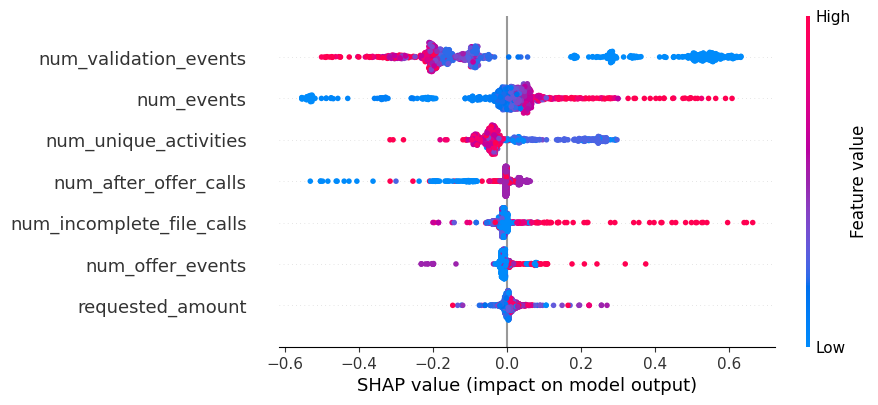

In [30]:
import shap

X_train_sample = X_train.sample(1000, random_state=42)
X_test_sample = X_test.sample(1000, random_state=42)

explainer = shap.Explainer(xgb.predict, X_train_sample)
shap_values = explainer(X_test_sample)

shap.plots.beeswarm(shap_values)

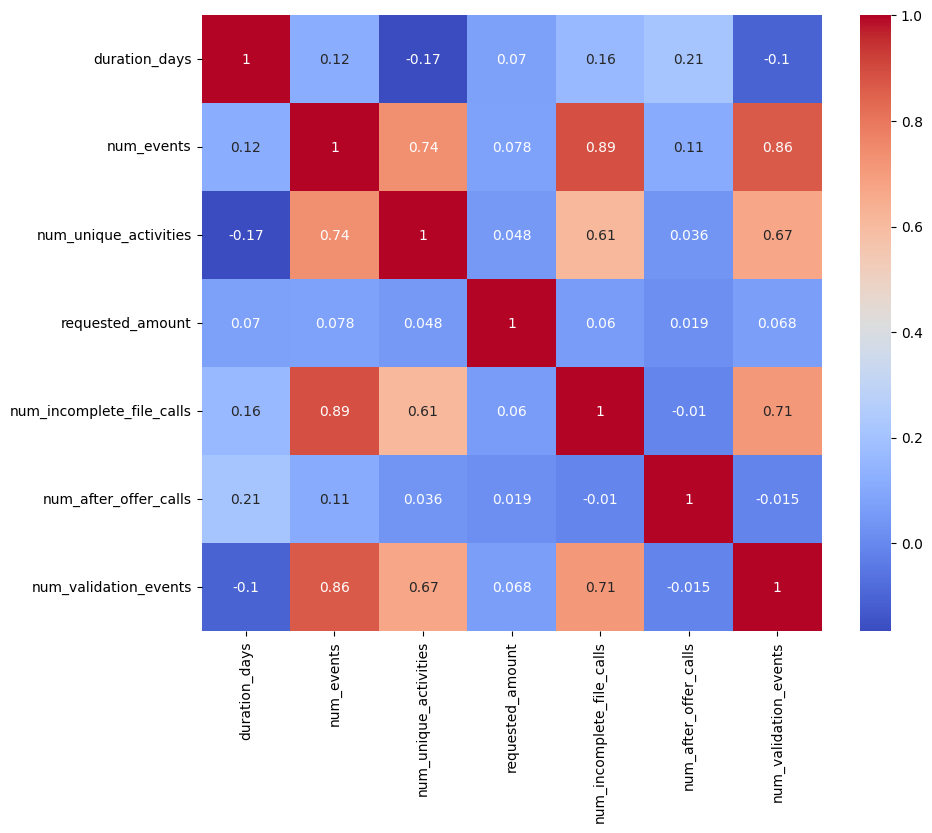

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    cases[
        [
            "duration_days",
            "num_events",
            "num_unique_activities",
            "requested_amount",
            "num_incomplete_file_calls",
            "num_after_offer_calls",
            "num_validation_events",
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
)

plt.show()

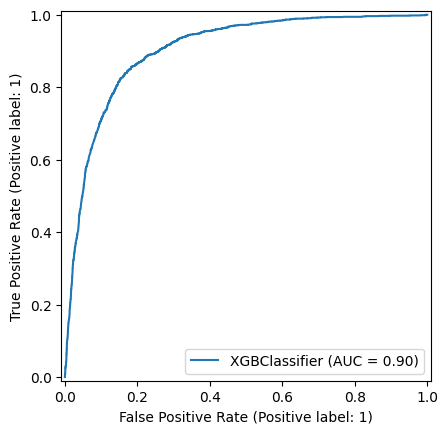

In [32]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
)

plt.show()

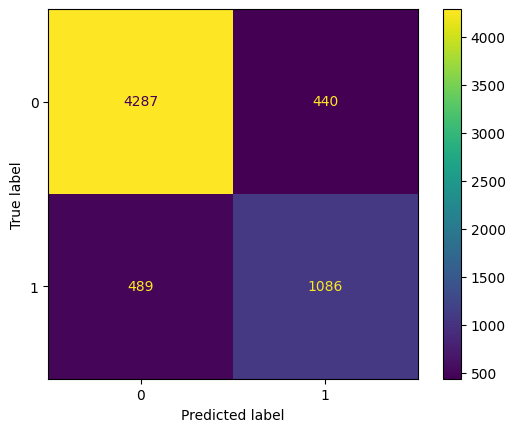

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
)

plt.show()

In [34]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba_xgb)
pr_auc = average_precision_score(y_test, y_proba_xgb)

roc_auc, pr_auc

(0.9030020718533518, 0.7309771680584751)

In [35]:
results = pd.DataFrame({
    "model": ["Random Forest", "XGBoost"],
    "accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb),
    ],
    "roc_auc": [
        roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_proba_xgb),
    ],
    "pr_auc": [
        average_precision_score(y_test, model.predict_proba(X_test)[:, 1]),
        average_precision_score(y_test, y_proba_xgb),
    ],
})

results

,model,accuracy,roc_auc,pr_auc
0,Random Forest,0.840685,0.878229,0.679553
1,XGBoost,0.852586,0.903002,0.730977


              precision    recall  f1-score   support

           0       0.92      0.86      0.89      4727
           1       0.66      0.79      0.72      1575

    accuracy                           0.85      6302
   macro avg       0.79      0.83      0.81      6302
weighted avg       0.86      0.85      0.85      6302



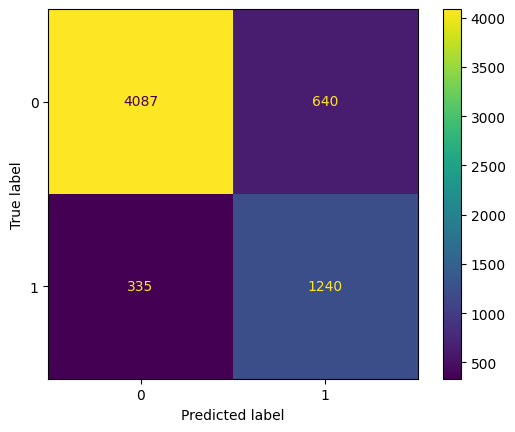

In [36]:
threshold = 0.35

y_pred_threshold = (y_proba_xgb >= threshold).astype(int)

print(classification_report(y_test, y_pred_threshold))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_threshold,
)

plt.show()

In [37]:
risk_scores = X_test.copy()
risk_scores["delay_probability"] = y_proba_xgb
risk_scores["actual_delayed"] = y_test.values

risk_scores["risk_segment"] = pd.cut(
    risk_scores["delay_probability"],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=["low", "medium", "high", "critical"],
)

risk_scores["risk_segment"].value_counts()

risk_segment
low         4128
high         989
medium       648
critical     537
Name: count, dtype: int64

In [38]:
risk_scores.groupby("risk_segment", observed=True).agg(
    cases=("delay_probability", "count"),
    avg_delay_probability=("delay_probability", "mean"),
    actual_delay_rate=("actual_delayed", "mean"),
).sort_index()

,cases,avg_delay_probability,actual_delay_rate
risk_segment,,,
low,4128,0.062524,0.057897
medium,648,0.360981,0.385802
high,989,0.635751,0.653185
critical,537,0.803108,0.819367


XGBoost mejora todas las métricas del modelo baseline, especialmente la capacidad de discriminar solicitudes con riesgo de retraso.

In [39]:
cases.to_csv(
    "../data/cases_dataset.csv",
    index=True
)

In [40]:
import joblib

joblib.dump(
    xgb,
    "../models/xgboost_delay_model.pkl"
)

['../models/xgboost_delay_model.pkl']

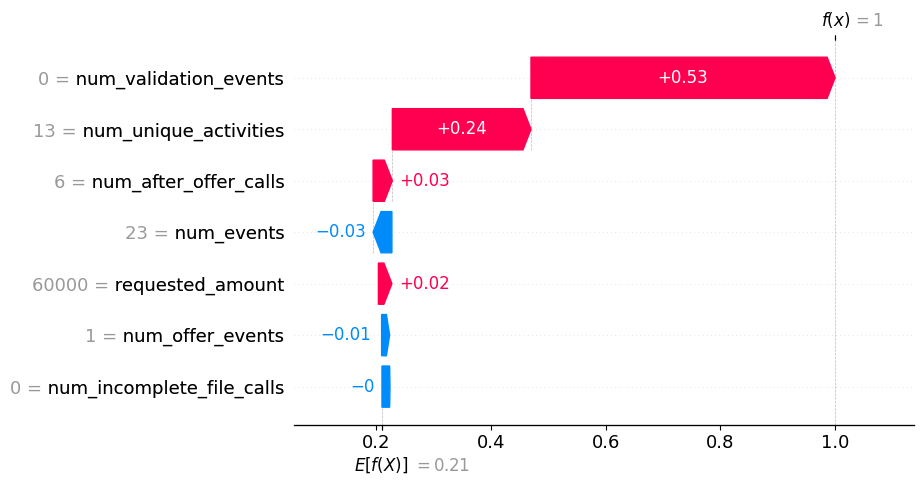

In [41]:
shap.plots.waterfall(
    shap_values[0]
)

Esta solicitud se considera de alto riesgo porque ha tenido muchas validaciones, muchas actividades distintas y múltiples llamadas posteriores a la oferta.

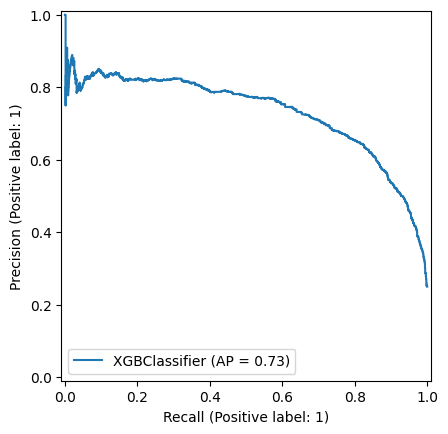

In [42]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
)

plt.show()

## Bayesian Operational Risk Modeling

This section estimates uncertainty around loan delay risk using Bayesian logistic regression.
Unlike XGBoost, the Bayesian model provides posterior distributions for the effect of each operational variable.

In [43]:
import pymc as pm
import arviz as az
import numpy as np

from sklearn.preprocessing import StandardScaler

/home/albert/Desktop/GITHUB/ml-studio/ml/loanops/.venv/lib/python3.10/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [44]:
bayesian_features = [
    "num_events",
    "num_validation_events",
    "num_incomplete_file_calls",
    "num_after_offer_calls",
    "requested_amount",
]

bayes_df = cases[bayesian_features + ["is_delayed"]].dropna()

X_bayes = bayes_df[bayesian_features]
y_bayes = bayes_df["is_delayed"].astype(int).values

scaler = StandardScaler()
X_bayes_scaled = scaler.fit_transform(X_bayes)

X_bayes_scaled.shape, y_bayes.shape

((31509, 5), (31509,))

In [45]:
from sklearn.model_selection import train_test_split

X_bayes_sample, _, y_bayes_sample, _ = train_test_split(
    X_bayes_scaled,
    y_bayes,
    train_size=5000,
    random_state=42,
    stratify=y_bayes,
)

X_bayes_sample.shape, y_bayes_sample.mean()

((5000, 5), np.float64(0.25))

In [46]:
with pm.Model() as bayesian_delay_model:
    alpha = pm.Normal("alpha", mu=0, sigma=2)

    beta = pm.Normal(
        "beta",
        mu=0,
        sigma=1,
        shape=X_bayes_sample.shape[1],
    )

    logits = alpha + pm.math.dot(X_bayes_sample, beta)

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(logits),
    )

    y_obs = pm.Bernoulli(
        "y_obs",
        p=p,
        observed=y_bayes_sample,
    )

    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
/home/albert/Desktop/GITHUB/ml-studio/ml/loanops/.venv/lib/python3.10/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.


In [47]:
az.summary(
    trace,
    var_names=["alpha", "beta"],
    hdi_prob=0.95,
)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.433,0.043,-1.518,-1.351,0.001,0.001,3473.0,2858.0,1.0
beta[0],1.594,0.119,1.340,1.810,0.002,0.002,2341.0,2166.0,1.0
beta[1],-2.392,0.106,-2.598,-2.183,0.002,0.002,2882.0,2620.0,1.0
beta[2],0.153,0.084,-0.003,0.327,0.002,0.001,2406.0,2466.0,1.0
beta[3],0.128,0.041,0.045,0.204,0.001,0.001,3249.0,2957.0,1.0
beta[4],0.053,0.037,-0.020,0.124,0.001,0.001,4183.0,2814.0,1.0


In [48]:
posterior_beta = trace.posterior["beta"]

for idx, feature in enumerate(bayesian_features):
    prob_positive = (posterior_beta[:, :, idx] > 0).mean().item()
    print(f"{feature}: P(beta > 0 | data) = {prob_positive:.3f}")

num_events: P(beta > 0 | data) = 1.000
num_validation_events: P(beta > 0 | data) = 0.000
num_incomplete_file_calls: P(beta > 0 | data) = 0.967
num_after_offer_calls: P(beta > 0 | data) = 0.999
requested_amount: P(beta > 0 | data) = 0.918


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n1'}>],
       [<Axes: title={'center': 'beta\n2'}>,
        <Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n4'}>]], dtype=object)

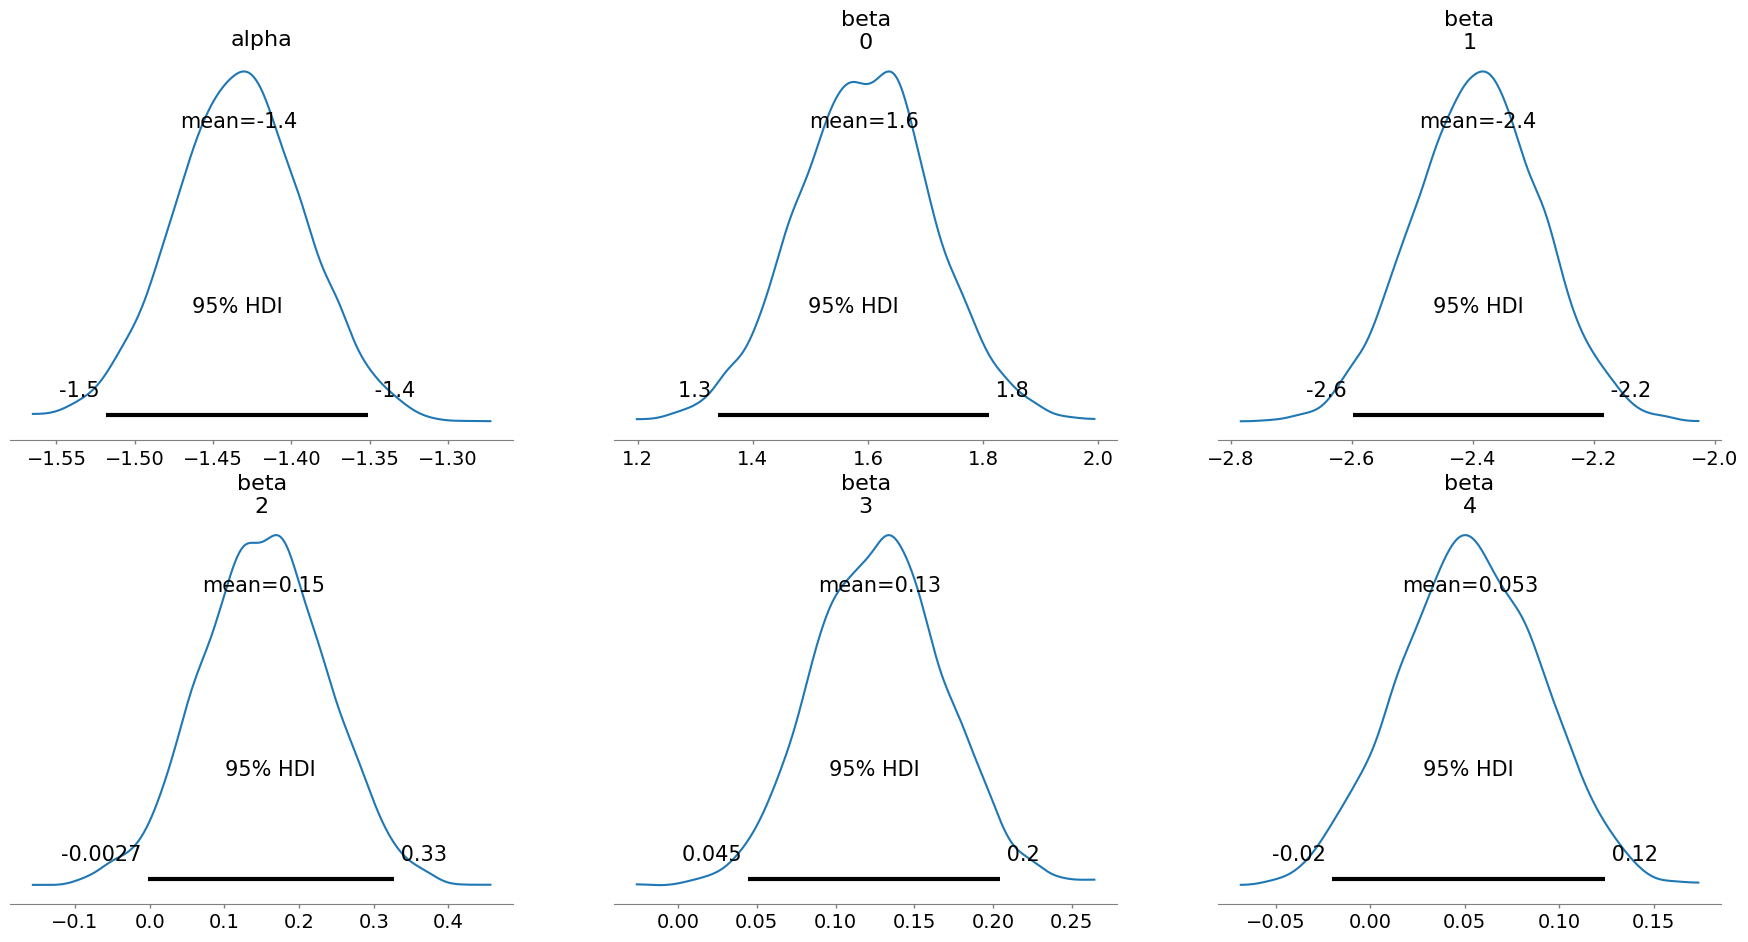

In [49]:
az.plot_posterior(
    trace,
    var_names=["alpha", "beta"],
    hdi_prob=0.95
)

In [50]:
credible_intervals = az.summary(
    trace,
    var_names=["alpha", "beta"],
    hdi_prob=0.95
)

credible_intervals

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.433,0.043,-1.518,-1.351,0.001,0.001,3473.0,2858.0,1.0
beta[0],1.594,0.119,1.340,1.810,0.002,0.002,2341.0,2166.0,1.0
beta[1],-2.392,0.106,-2.598,-2.183,0.002,0.002,2882.0,2620.0,1.0
beta[2],0.153,0.084,-0.003,0.327,0.002,0.001,2406.0,2466.0,1.0
beta[3],0.128,0.041,0.045,0.204,0.001,0.001,3249.0,2957.0,1.0
beta[4],0.053,0.037,-0.020,0.124,0.001,0.001,4183.0,2814.0,1.0


In [51]:
bayesian_summary = az.summary(
    trace,
    var_names=["beta"],
    hdi_prob=0.95
).copy()

bayesian_summary.index = bayesian_features

bayesian_summary[
    ["mean", "sd", "hdi_2.5%", "hdi_97.5%", "r_hat"]
]

,mean,sd,hdi_2.5%,hdi_97.5%,r_hat
num_events,1.594,0.119,1.340,1.810,1.0
num_validation_events,-2.392,0.106,-2.598,-2.183,1.0
num_incomplete_file_calls,0.153,0.084,-0.003,0.327,1.0
num_after_offer_calls,0.128,0.041,0.045,0.204,1.0
requested_amount,0.053,0.037,-0.020,0.124,1.0


In [52]:
bayesian_summary["effect_direction"] = bayesian_summary.apply(
    lambda row: "positive" if row["hdi_2.5%"] > 0 else "negative" if row["hdi_97.5%"] < 0 else "uncertain",
    axis=1
)

bayesian_summary[
    ["mean", "hdi_2.5%", "hdi_97.5%", "effect_direction", "r_hat"]
]

,mean,hdi_2.5%,hdi_97.5%,effect_direction,r_hat
num_events,1.594,1.340,1.810,positive,1.0
num_validation_events,-2.392,-2.598,-2.183,negative,1.0
num_incomplete_file_calls,0.153,-0.003,0.327,uncertain,1.0
num_after_offer_calls,0.128,0.045,0.204,positive,1.0
requested_amount,0.053,-0.020,0.124,uncertain,1.0


Más eventos → mayor riesgo.

Muchas validaciones → menor riesgo.

Llamadas posteriores a la oferta → más riesgo.

Importe solicitado → no parece importante.

Ficheros incompletos → efecto débil.


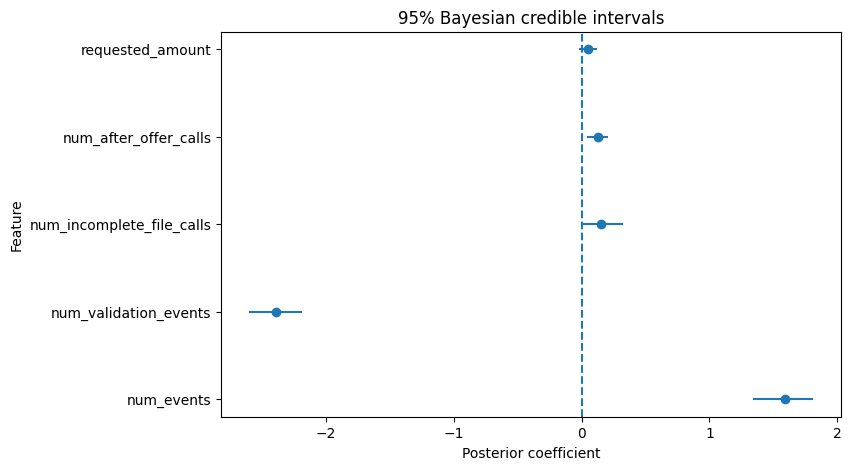

In [53]:
effects = bayesian_summary.reset_index()

plt.figure(figsize=(8,5))

plt.errorbar(
    effects["mean"],
    effects["index"],
    xerr=[
        effects["mean"] - effects["hdi_2.5%"],
        effects["hdi_97.5%"] - effects["mean"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--")
plt.xlabel("Posterior coefficient")
plt.ylabel("Feature")
plt.title("95% Bayesian credible intervals")

plt.show()

The Bayesian model estimates uncertainty around the operational effects.

Variables whose 95% credible interval excludes zero can be considered robust predictors of delay risk.

The number of validation events shows a strong negative effect, while the total number of events and after-offer calls increase the probability of delayed cases.